
FOOD101 - SPLIT 1%
Train subset size (1%): 606
Validation size: 15150
Test size: 25250

=== WARIANT A: Feature Extraction | 1% ===
[FeatureExtraction_1%] Epoch 1/3 | Train Loss: 4.6369 | Val Loss: 4.5578 | Val Acc: 0.0391
[FeatureExtraction_1%] Epoch 2/3 | Train Loss: 3.8415 | Val Loss: 4.3644 | Val Acc: 0.1022
[FeatureExtraction_1%] Epoch 3/3 | Train Loss: 3.3006 | Val Loss: 4.1792 | Val Acc: 0.1228

=== WARIANT B: Fine-Tuning Layer4 | 1% ===
[FineTuning_1%] Epoch 1/3 | Train Loss: 4.6189 | Val Loss: 4.5955 | Val Acc: 0.0205
[FineTuning_1%] Epoch 2/3 | Train Loss: 4.3891 | Val Loss: 4.5482 | Val Acc: 0.0358
[FineTuning_1%] Epoch 3/3 | Train Loss: 4.0836 | Val Loss: 4.4747 | Val Acc: 0.0585

[TEST] Feature Extraction (1%): 0.1349
[TEST] Fine-Tuning       (1%): 0.0615


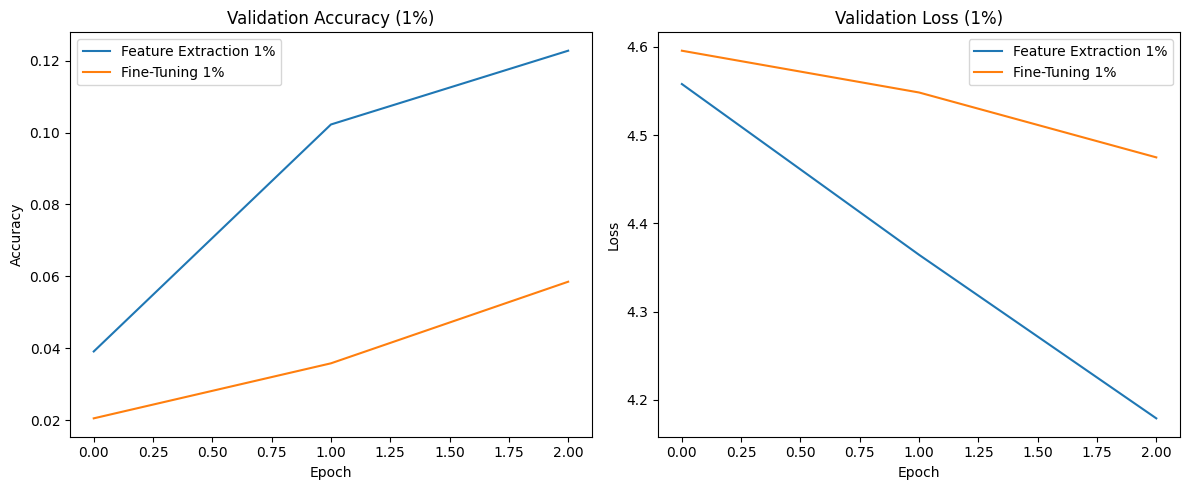


FOOD101 - SPLIT 10%
Train subset size (10%): 6060
Validation size: 15150
Test size: 25250

=== WARIANT A: Feature Extraction | 10% ===
[FeatureExtraction_10%] Epoch 1/3 | Train Loss: 3.9103 | Val Loss: 3.2742 | Val Acc: 0.3438
[FeatureExtraction_10%] Epoch 2/3 | Train Loss: 2.7386 | Val Loss: 2.7482 | Val Acc: 0.4242
[FeatureExtraction_10%] Epoch 3/3 | Train Loss: 2.1669 | Val Loss: 2.5144 | Val Acc: 0.4523

=== WARIANT B: Fine-Tuning Layer4 | 10% ===
[FineTuning_10%] Epoch 1/3 | Train Loss: 4.1342 | Val Loss: 3.1359 | Val Acc: 0.3293
[FineTuning_10%] Epoch 2/3 | Train Loss: 2.5184 | Val Loss: 2.1595 | Val Acc: 0.4884
[FineTuning_10%] Epoch 3/3 | Train Loss: 1.6465 | Val Loss: 1.8357 | Val Acc: 0.5525

[TEST] Feature Extraction (10%): 0.4877
[TEST] Fine-Tuning       (10%): 0.5966


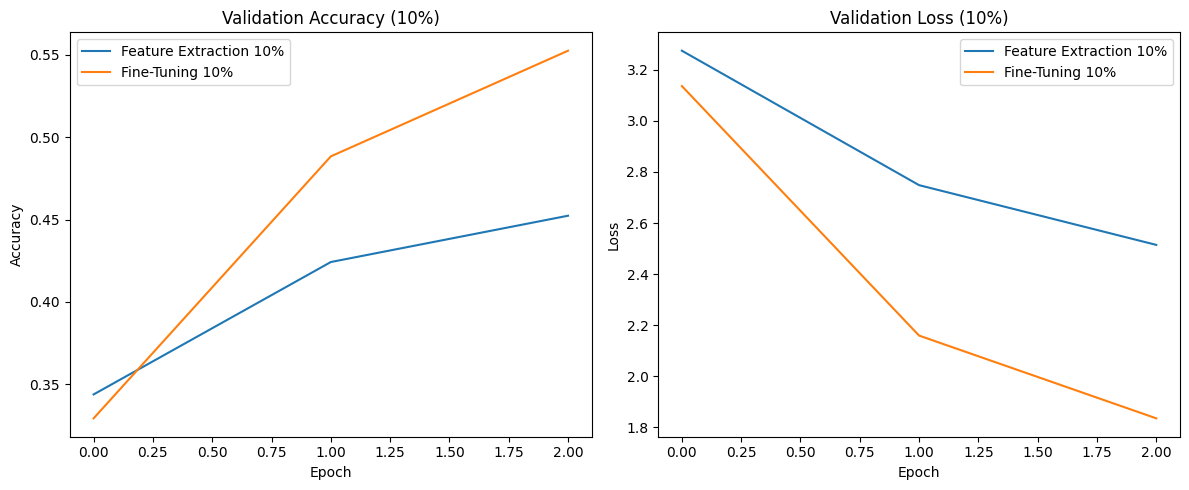


PODSUMOWANIE
1%:
  Feature Extraction Test Acc = 0.1349
  Fine-Tuning Test Acc       = 0.0615
10%:
  Feature Extraction Test Acc = 0.4877
  Fine-Tuning Test Acc       = 0.5966


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import models, transforms
from torchvision.datasets import Food101
import matplotlib.pyplot as plt


# ==========================================
# 1. CONFIG
# ==========================================
BATCH_SIZE = 32
NUM_CLASSES = 101
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# krócej, żeby szybciej działało
EPOCHS_HEAD = 3
EPOCHS_FINETUNE = 3
EARLY_STOPPING_PATIENCE = 1


# ==========================================
# 2. Food101 DATALOADERS
# ==========================================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

# Pobieranie datasetu
full_train = Food101(root="./data", split="train", download=True, transform=train_transform)
test_set = Food101(root="./data", split="test", download=True, transform=test_transform)

# Train/Val split
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size

train_set, val_set = random_split(full_train, [train_size, val_size])

val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


def get_subset(dataset, percent):
    size = len(dataset)
    subset_size = max(1, int(size * percent))
    indices = torch.randperm(size)[:subset_size]
    return Subset(dataset, indices)


# ==========================================
# 3. UNIVERSAL TRAINING FUNCTION + EARLY STOPPING
# ==========================================
def train_model(model, criterion, optimizer, train_loader, val_loader,
                epochs, name="Model", patience=1):

    train_losses, val_losses, val_accs = [], [], []
    best_loss = float("inf")
    no_improve = 0
    best_state = None

    model.to(DEVICE)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        acc = correct / total

        val_losses.append(val_loss)
        val_accs.append(acc)

        print(f"[{name}] Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {acc:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses, val_accs


# ==========================================
# 4. TEST FUNCTION
# ==========================================
def evaluate_model(model, test_loader):
    model.to(DEVICE)
    model.eval()

    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


# ==========================================
# 5. EXPERIMENTS: 1% and 10%
# ==========================================
results = {}

for split_name, percent in [("1%", 0.01), ("10%", 0.10)]:
    print("\n" + "=" * 60)
    print(f"FOOD101 - SPLIT {split_name}")
    print("=" * 60)

    train_subset = get_subset(train_set, percent)
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)

    print(f"Train subset size ({split_name}): {len(train_subset)}")
    print(f"Validation size: {len(val_set)}")
    print(f"Test size: {len(test_set)}")

    criterion = nn.CrossEntropyLoss()

    # ==========================================
    # WARIANT A — FEATURE EXTRACTION
    # ==========================================
    feature_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    for p in feature_model.parameters():
        p.requires_grad = False

    feature_model.fc = nn.Linear(feature_model.fc.in_features, NUM_CLASSES)

    optimizer_A = optim.Adam(feature_model.fc.parameters(), lr=1e-3)

    print(f"\n=== WARIANT A: Feature Extraction | {split_name} ===")
    A_train, A_val, A_acc = train_model(
        feature_model,
        criterion,
        optimizer_A,
        train_loader,
        val_loader,
        epochs=EPOCHS_HEAD,
        name=f"FeatureExtraction_{split_name}",
        patience=EARLY_STOPPING_PATIENCE
    )

    test_acc_A = evaluate_model(feature_model, test_loader)

    # ==========================================
    # WARIANT B — FINE TUNING
    # ==========================================
    finetune_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    for p in finetune_model.parameters():
        p.requires_grad = False

    for p in finetune_model.layer4.parameters():
        p.requires_grad = True

    finetune_model.fc = nn.Linear(finetune_model.fc.in_features, NUM_CLASSES)

    optimizer_B = optim.Adam(
        filter(lambda p: p.requires_grad, finetune_model.parameters()),
        lr=1e-4
    )

    print(f"\n=== WARIANT B: Fine-Tuning Layer4 | {split_name} ===")
    B_train, B_val, B_acc = train_model(
        finetune_model,
        criterion,
        optimizer_B,
        train_loader,
        val_loader,
        epochs=EPOCHS_FINETUNE,
        name=f"FineTuning_{split_name}",
        patience=EARLY_STOPPING_PATIENCE
    )

    test_acc_B = evaluate_model(finetune_model, test_loader)

    print(f"\n[TEST] Feature Extraction ({split_name}): {test_acc_A:.4f}")
    print(f"[TEST] Fine-Tuning       ({split_name}): {test_acc_B:.4f}")

    results[split_name] = {
        "A_test": test_acc_A,
        "B_test": test_acc_B,
        "A_acc": A_acc,
        "B_acc": B_acc,
        "A_val": A_val,
        "B_val": B_val
    }

    # ==========================================
    # WYKRESY
    # ==========================================
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(A_acc, label=f"Feature Extraction {split_name}")
    plt.plot(B_acc, label=f"Fine-Tuning {split_name}")
    plt.title(f"Validation Accuracy ({split_name})")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(A_val, label=f"Feature Extraction {split_name}")
    plt.plot(B_val, label=f"Fine-Tuning {split_name}")
    plt.title(f"Validation Loss ({split_name})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ==========================================
# 6. SUMMARY
# ==========================================
print("\n" + "=" * 60)
print("PODSUMOWANIE")
print("=" * 60)

for split_name in results:
    print(f"{split_name}:")
    print(f"  Feature Extraction Test Acc = {results[split_name]['A_test']:.4f}")
    print(f"  Fine-Tuning Test Acc       = {results[split_name]['B_test']:.4f}")

---

## 1️⃣ Import modelu + weights

```python
from torchvision.models import convnext_base, ConvNeXt_Base_Weights

model = convnext_base(weights=ConvNeXt_Base_Weights.IMAGENET1K_V1)
```

dla EfficientNet:

```python
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
```

dla ViT:

```python
from torchvision.models import vit_b_16, ViT_B_16_Weights
model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
```

---

## 2️⃣ Zamrożenie warstw (feature extraction)

```python
for param in model.parameters():
    param.requires_grad = False
```

Możesz też odmrozić część (fine-tuning).

---

## 3️⃣ Podmiana klasyfikatora (tail)

Każdy model kończy się inną warstwą:

| Model        | Ostatnia warstwa      |
| ------------ | --------------------- |
| ResNet       | `model.fc`            |
| ConvNeXt     | `model.classifier[2]` |
| EfficientNet | `model.classifier[1]` |
| ViT          | `model.heads.head`    |
| Swin         | `model.head`          |
| RegNet       | `model.fc`            |

---

### Przykład:

```python
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
```

---

## 4️⃣ Trening — identyczny jak wcześniej

```python
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
```

---

# ⭐ Przykład 1: **ConvNeXt Base**


```python
from torchvision.models import convnext_base, ConvNeXt_Base_Weights

model = convnext_base(weights=ConvNeXt_Base_Weights.IMAGENET1K_V1)

for p in model.parameters():
    p.requires_grad = False

# Zamieniamy classifier: ConvNeXt → classifier[2]
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
```

To wszystko — model gotowy do TL.

---

# ⭐ Przykład 2: **EfficientNet-B0**

```python
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze
for p in model.parameters():
    p.requires_grad = False

# EfficientNet → classifier[1]
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, NUM_CLASSES)
```

---

# ⭐ Przykład 3: **Vision Transformer ViT-B/16**

```python
from torchvision.models import vit_b_16, ViT_B_16_Weights

model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

# Freeze
for p in model.parameters():
    p.requires_grad = False

# Head zmieniamy w Transformerze
in_feats = model.heads.head.in_features
model.heads.head = nn.Linear(in_feats, NUM_CLASSES)
```

---

# ⭐ Przykład 4: **Swin Transformer V2-B**

```python
from torchvision.models import swin_v2_b, Swin_V2_B_Weights

model = swin_v2_b(weights=Swin_V2_B_Weights.IMAGENET1K_V1)

# Freeze
for p in model.parameters():
    p.requires_grad = False

# Głowica klasyfikacji
in_feats = model.head.in_features
model.head = nn.Linear(in_feats, NUM_CLASSES)
```

---

# ⭐ Przykład 5: **RegNet-Y 16GF**

```python
from torchvision.models import regnet_y_16gf, RegNet_Y_16GF_Weights

model = regnet_y_16gf(weights=RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_E2E_V1)

for p in model.parameters():
    p.requires_grad = False

in_feats = model.fc.in_features
model.fc = nn.Linear(in_feats, NUM_CLASSES)
```
